In [5]:
from typing import TypedDict

class BlogState(TypedDict):
    topic: str
    intro: str
    example: str
    code: str
    final_blog: str

In [6]:
def planner(state: BlogState):
    return state

def write_intro(state: BlogState):
    return {
        "intro": f"Introduction to {state['topic']}"
    }

def write_examples(state: BlogState):
    return {
        "example": f"Examples of {state['topic']}"
    }

def write_codes(state: BlogState):
    return {
        "code": f"Codes of {state['topic']}"
    }

def merger(state: BlogState):
    final_blog = (
        state['intro'] + '\n' + state['example'] + '\n' + state['code']
    )
    return {'final_blog': final_blog}

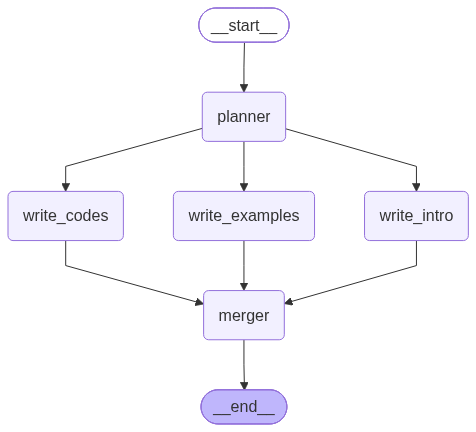

In [7]:
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

graph = StateGraph(BlogState)

graph.add_node("planner", planner)
graph.add_node("write_intro", write_intro)
graph.add_node("write_examples", write_examples)
graph.add_node("write_codes", write_codes)
graph.add_node("merger", merger)

graph.add_edge(START, "planner")

# Fan-Out
graph.add_edge("planner", "write_intro")
graph.add_edge("planner", "write_examples")
graph.add_edge("planner", "write_codes")

graph.add_edge("write_intro", "merger")
graph.add_edge("write_examples", "merger")
graph.add_edge("write_codes", "merger")

graph.add_edge("merger", END)

graph_app = graph.compile()
graph_app


In [8]:
result = graph_app.invoke({
    "topic": "Explain Gen AI"
})

print(result["final_blog"])

Introduction to Explain Gen AI
Examples of Explain Gen AI
Codes of Explain Gen AI
